# Validación

(4 puntos totales)

Hasta el momento hemos logrado entrenar la red, es decir, encontrar los pesos tal que se reduce el error entre la salida de la red y la salida esperada. Con los pesos entrenados, la red pude predecir la clase que corresponde a una entrada que no ha visto. Este proceso de predicción conocido como inferencia es la parte más interesante de las redes ya que permite generalizar su uso a casos no vistos. Sin embargo, durante el entrenamiento se puede suscitar un fenómeno conocido como sobre-ajuste (overfitting), donde la red reduce de manera adecuada la pérdida con respecto a los datos de entrenamiento, pero al momento de encontrarse con ejemplos desconocidos, ésta tiene un rendimiento pobre. Este efecto es contrario, por que buscamos **generalizar** el rendimiento de tal forma que clasifique bien ejemplos que no han sido vistos. 

Para saber que tan bien está generalizando la red se realiza un proceso de validación. En este proceso de validación se verifican las predicciones de la red en un conjunto de datos de validación. También haremos uso de *dropout*, una técnica de regularización que ayuda a reducir el sobre-ajuste.


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/irvingvasquez/practicas_pytorch/blob/master/05_validacion.ipynb)

@juan1rving

In [7]:
# Cargamos paquetes necesarios
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import matplotlib.pyplot as plt
import numpy as np
import time

import torch
from torch import nn
from torch import optim
import torch.nn.functional as F
from torchvision import datasets, transforms

# helper was developed by Udacity under MIT license. Paquete disponible en el repositorio del curso.
import helper

## Conjunto de datos (Dataset)

Para este ejemplo utilizaremos el Fashion MNIST. Este dataset esta constituido por imágenes de 28 x 28 pixeles y cada imagen contiene prendas como ropa o zapatos.  

In [8]:
# Semilla para reproducibilidad
# NOTE: No modificar esta sección, es importante para la reproducibilidad de los resultados.
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

# Definimos una transformación de los datos
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Descargamos el conjunto completo de entrenamiento
full_trainset = datasets.FashionMNIST(
    'F_MNIST_data/', download=True, train=True, transform=transform
)

# Partición reproducible en subconjuntos (por ejemplo 80% train, 20% validación)
train_size = int(0.8 * len(full_trainset))
val_size = len(full_trainset) - train_size

split_generator = torch.Generator().manual_seed(seed)
trainset, validationset = torch.utils.data.random_split(
    full_trainset, [train_size, val_size], generator=split_generator
)

# DataLoaders reproducibles
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=64, shuffle=True, generator=torch.Generator().manual_seed(seed)
)
validationloader = torch.utils.data.DataLoader(
    validationset, batch_size=64, shuffle=False
)

## Red Neuronal

En esta ocasión, construiremos la red de forma más general, donde las capas ocultas se generarán a partir de un vector que indica el número de capas y el número de nodos de cada capa. Haremos uso del módulo *nn.ModuleList* que nos permitirá crear un número arbitrario de capas. En cierta forma *nn.ModuleList* se comporta como una lista simple de python. 

In [9]:
#NOTE: No modificar esta sección, es importante para la reproducibilidad de los resultados.
class RedNeuronal(nn.Module):
    def __init__(self, input_size, output_size, hidden_layers, drop_p = 0.5):
        '''
        Construye una red de tamaño arbitrario.
        
        Parámetros:
        input_size: cantidad de elementos en la entrada
        output_size: cantidada de elementos en la salida 
        hidden_layers: cantidad de elementos por cada capa oculta
        drop_p: probabilidad de "tirar" (drop) una neurona [0,1] 
        '''
        # llamamos al constructor de la superclase
        super().__init__()
        
        # Agregamos la primera capa
        self.hidden_layers = nn.ModuleList([nn.Linear(input_size, hidden_layers[0])])
        
        # agregamos cada una de las capas, zip empareja el número de entradas con las salidas
        layer_sizes = zip(hidden_layers[:-1], hidden_layers[1:])
        self.hidden_layers.extend([nn.Linear(h1, h2) for h1, h2 in layer_sizes])
        
        # agregamos la capa de salida final de la red
        self.output = nn.Linear(hidden_layers[-1], output_size)
        
        # Incluimos drop-out en la red
        self.dropout = nn.Dropout(p=drop_p)
        
    def forward(self, x):
        ''' Pase hacia adelante en la red, el regreso son las probabilidades en el dominio log '''
        
        # Hacemos un pase frontal en cada una de las capas ocultas, 
        # La funció de activación es un RELU combinado con dropout
        for linear in self.hidden_layers:
            x = F.relu(linear(x))
            x = self.dropout(x)
        
        x = self.output(x)
        
        return F.log_softmax(x, dim=1)

## Entrenamiento

Ahora entrenaremos la red tal cual lo hemos visto en sesiones previas.

La pérdida (loss) nos indica que tan bien o mal está clasificando nuestra red. Dado que estamos utilizando el dominio log para calcular las salidas de la red, utilizaremos el criterio negative log loss *nn.NLLLoss()*. Como optimizador utilzaremos SGD optimizer, el cual permite intercambiar los lotes de entrenamiento para reducir la caida en minimos locales.

In [ ]:
# NOTE: Si lo desea puede modificar los hiperparámetros, pero no es necesario para obtener buenos resultados.
tasa_de_aprendizaje = 0.01
probabilidad_de_dropout = 0.2

# Tambien si lo desea puede modificar la arquitectura de la red.
model = RedNeuronal(784, 10, [516, 256], drop_p=probabilidad_de_dropout)
criterion = nn.NLLLoss()

# NOTE: Puede cambiar el optimizador, pero ADAM no esta permitido.
# Las alternativas son: optim.SGD, optim.RMSprop, optim.Adagrad, optim.Adadelta, optim.Adamax, optim.ASGD, optim.LBFGS
optimizer = optim.SGD(model.parameters(), lr=tasa_de_aprendizaje)

Ahora programaremos la validación. En esta etapa se mide la exactitud de la red en el conjunto de validación a fin de ver que tan bien está generalizando la red. Como estamos utilizando drop out durante el entrenamiento al momento de hacer una inferencia este proceso se debe desactivar. Afortunadamente pytorch provee dos modos de funcionamiento para la red: entrenamiento o evaluación, model.train() y model.eval() respectivamente.

Recuerda que la validación se verá como sigue:
```
    with torch.no_grad(): # se desactivan los gradientes
        test_loss, accuracy = validation(model, validationloader, criterion) #se llama a la funcion de validación
```

In [17]:
# Implementamos una función de validación.
def validation(model, validationloader, criterion):
    test_loss = 0
    accuracy = 0
    for images, labels in validationloader:

        images.resize_(images.shape[0], 784)

        output = model.forward(images)
        test_loss += criterion(output, labels).item()

        ps = torch.exp(output)
        equality = (labels.data == ps.max(dim=1)[1])
        accuracy += equality.type(torch.FloatTensor).mean()
    
    return test_loss, accuracy

Implementación del entrenamiento y validación por épocas



In [13]:
# Hiperparámetros
epochs = 2
steps = 0
running_loss = 0
print_every = 40

In [ ]:

# Historial de pérdidas
train_losses = []
val_losses = []

for e in range(epochs):
    model.train()
    epoch_train_loss = 0

    for images, labels in trainloader:
        steps += 1

        # Aplanar imágenes
        images = images.view(images.size(0), 784)

        optimizer.zero_grad()

        output = model.forward(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        epoch_train_loss += loss.item()

        if steps % print_every == 0:
            #TODO: (1 pt) desactiva los gradientes y calcula la pérdida y exactitud en el conjunto de validación )
            test_loss, accuracy = None

            print("Epoch: {}/{}.. ".format(e + 1, epochs),
                  "Pérdida de entrenamiento: {:.3f}.. ".format(running_loss / print_every),
                  "Pérdida de validación: {:.3f}.. ".format(test_loss / len(validationloader)),
                  "Exactitud de validación: {:.3f}".format(accuracy / len(validationloader)))

            running_loss = 0
            model.train()

    # Guardar pérdidas por época
    model.eval()
    with torch.no_grad():
        test_loss, accuracy = validation(model, validationloader, criterion)

    train_losses.append(epoch_train_loss / len(trainloader))
    val_losses.append(test_loss / len(validationloader))

Epoch: 1/2..  Pérdida de entrenamiento: 0.910..  Pérdida de validación: 0.846..  Exactitud de validación: 0.720
Epoch: 1/2..  Pérdida de entrenamiento: 0.861..  Pérdida de validación: 0.802..  Exactitud de validación: 0.732
Epoch: 1/2..  Pérdida de entrenamiento: 0.832..  Pérdida de validación: 0.776..  Exactitud de validación: 0.734
Epoch: 1/2..  Pérdida de entrenamiento: 0.793..  Pérdida de validación: 0.747..  Exactitud de validación: 0.740
Epoch: 1/2..  Pérdida de entrenamiento: 0.768..  Pérdida de validación: 0.727..  Exactitud de validación: 0.743
Epoch: 1/2..  Pérdida de entrenamiento: 0.739..  Pérdida de validación: 0.711..  Exactitud de validación: 0.748
Epoch: 1/2..  Pérdida de entrenamiento: 0.732..  Pérdida de validación: 0.689..  Exactitud de validación: 0.756
Epoch: 1/2..  Pérdida de entrenamiento: 0.720..  Pérdida de validación: 0.683..  Exactitud de validación: 0.747
Epoch: 1/2..  Pérdida de entrenamiento: 0.688..  Pérdida de validación: 0.671..  Exactitud de validación

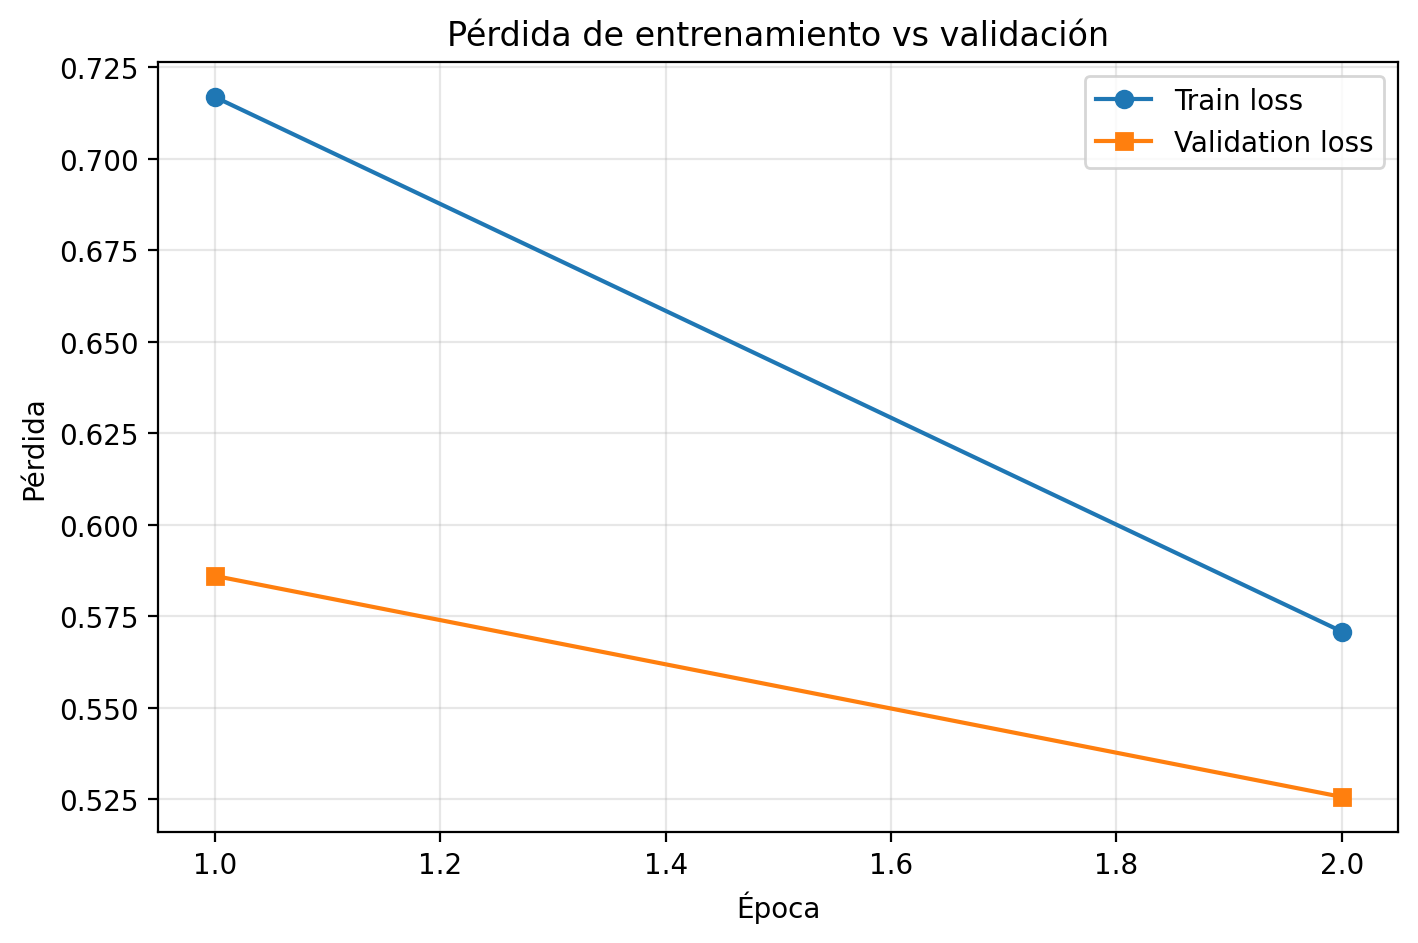

In [15]:

# Gráfica de pérdidas
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_losses, marker='o', label='Train loss')
plt.plot(range(1, epochs + 1), val_losses, marker='s', label='Validation loss')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.title('Pérdida de entrenamiento vs validación')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Inferencia

Ahora que ya hemos entrenado la red vamos a probar cual es su rendimiento en la clasificación de las prendas de vestir. 

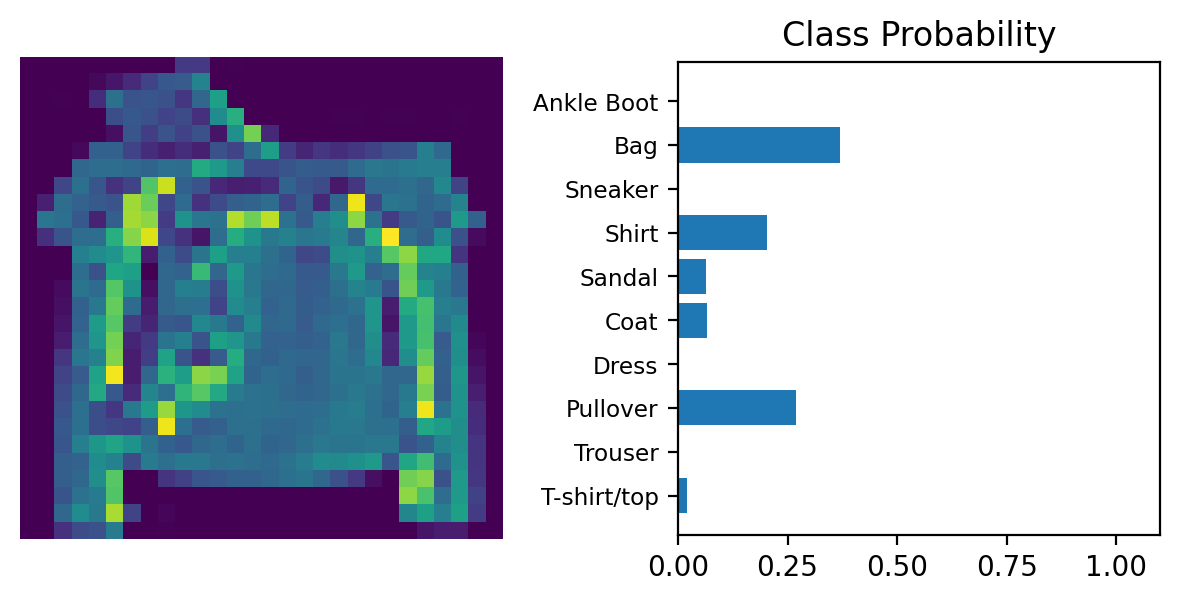

In [16]:
# Probemos la red!
model.eval()

dataiter = iter(validationloader)
images, labels = next(dataiter)
img = images[0]
# Aplanamos la imagenes
img = img.view(1, 784)

# Estimamos para cada imagen la probabilidad de pertenencia a una clase (softmax)
with torch.no_grad():
    output = model.forward(img)

ps = torch.exp(output)

# Graficamos
helper.view_classify(img.view(1, 28, 28), ps, version='Fashion')

## Actividad:

Realiza lo siguiente: 

Entrena el modelo para que:
1) (1 pt) Alcances una exactitude de validación superior al 87% (Coloca aqui los hiperparámetros que usaste)
2) (2 pt) Alcanza un sobre ajuste de la red (se debe mostrar sobre la gráfica) Esto nos indicará el punto a partir del cual ya no conviene seguir entrenando.